<a href="https://colab.research.google.com/github/furalmiqbadi/PCVK26_01_AbdulGhofurAlmiqbadi/blob/main/Week3_01_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Persiapan

In [ ]:
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Abdul Ghofur Almiqbadi'
NIM = '244107020155'

N = int(NIM[-3:])
PARAM = {
    'b': (N % 61) + 20,
    'a': round(1.0 + (N % 9) / 10, 1),
    'c': (N % 20) + 30,
    'gamma': round(0.4 + (N % 6) * 0.25, 2),
    'bit': (N % 6) + 2,
}

waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA  :', NAMA)
print('NIM   :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s:' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM:', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA  : Abdul Ghofur Almiqbadi
NIM   : 244107020155 | N = 155
b     : 53
a     : 1.2
c     : 45
gamma : 1.65
bit   : 7
WAKTU : 2026-09-18 16:16:44 WIB
SISTEM: 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : d778c08b6d57c914


In [ ]:
# akses google drive
from google.colab import drive
drive.mount('/content/drive')

# import library
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob

from math import log10, sqrt
from google.colab.patches import cv2_imshow

# tentukan base folder sesuai NIM
base = '/content/drive/MyDrive/3-Tugas/PCVK/'

Mounted at /content/drive


# Praktikum

## Transformasi linier brightness

Mengubah tingkat kecerahan citra
--------------------------------
Masukkan nilai kecerahan:30


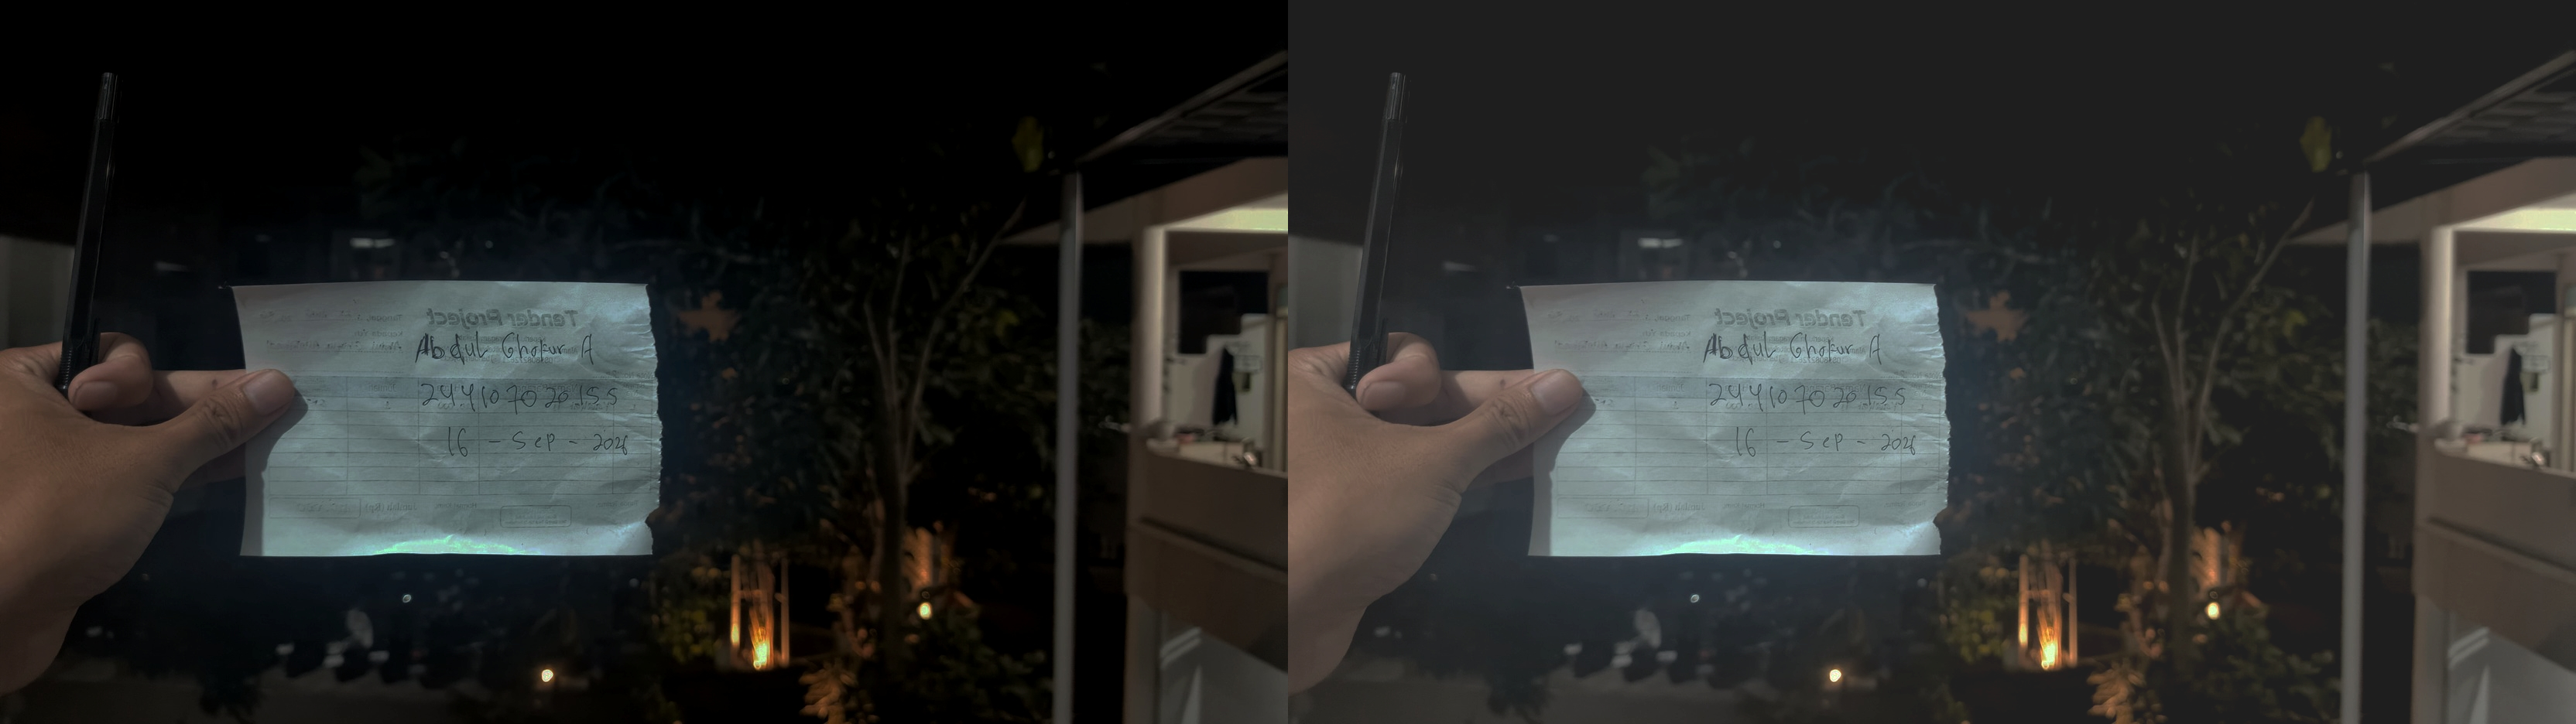

In [34]:
print ('Mengubah tingkat kecerahan citra')
print ('--------------------------------')

try:
  brightness = int(input('Masukkan nilai kecerahan:'))
except ValueError:
  print('Error, not a number')

#ambil foto
original = cv.imread(base + '/NIGHT1.jpg')

#buat wadah
brightness_image = np.zeros(original.shape, original.dtype)

#akses per pixel
for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c] = np.clip(original[y,x,c].astype(np.int16) + brightness, 0, 255)

#cara simple tanpa perulangan
# brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

## TUGAS PRAKTIKUM

### Transformasi Inverse Citra (Negatif)

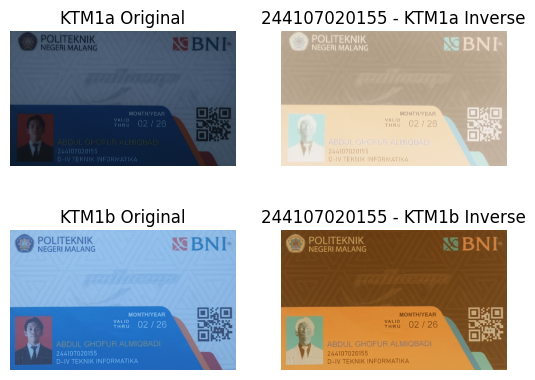

In [ ]:
# baca citra
img_a = cv.imread(base + '/KTM1a.jpg')
img_b = cv.imread(base + '/KTM1b.jpg')

# hitung inverse (255 - pixel)
inv_a = 255 - img_a
inv_b = 255 - img_b

# menampilkan
plt.subplot(2,2,1)
plt.imshow(cv.cvtColor(img_a, cv.COLOR_BGR2RGB))
plt.title('KTM1a Original')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(cv.cvtColor(inv_a, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1a Inverse')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(cv.cvtColor(img_b, cv.COLOR_BGR2RGB))
plt.title('KTM1b Original')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(cv.cvtColor(inv_b, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1b Inverse')
plt.axis('off')

plt.show()

1. Mengapa Negatif KTM1a atau Ruangan Gelap Tampak Pucat dan Berkabut?
Karena citra aslinya didominasi oleh piksel yang sangat gelap atau nilai mendekati 0. Saat diinversi, seluruh piksel gelap ini berubah menjadi sangat terang atau mendekati 255. Karena tidak ada piksel gelap yang tersisa dan variasi warnanya menyempit maka citra negatifnya menjadi seragam terang, pucat, dan kehilangan kontras.
2. Mengapa Negatif KTM1b Tetap Kontras?
Karena citra aslinya memiliki pencahayaan yang baik, sehingga nilai pikselnya tersebar merata dari gelap, sedang, hingga terang. Saat diinversi, piksel gelap ditukar menjadi terang, dan piksel terang ditukar menjadi gelap. Karena variasi intensitas aslinya lengkap ini sehingga proses inversi hanya membalik warna tanpa menghilangkan perbedaan gelap-terang, sehingga kontras dan detail citra tetap terjaga dengan jelas.

### Transformasi Contrast


Mengubah kontras dan tingkat kecerahan citra
-------------------------------------------
Masukkan tingkat kecerahan: 10
Nilai kontras: 1.2


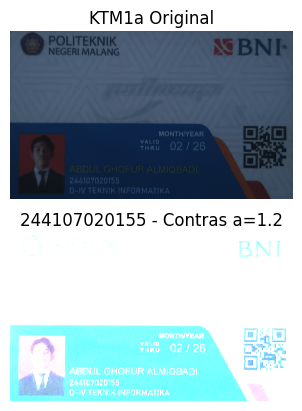

In [ ]:
# baca citra ktm1a
img_a = cv.imread(base + '/KTM1a.jpg')

# input nilai
print('Mengubah kontras dan tingkat kecerahan citra')
print('-------------------------------------------')

try:
    brightness = int(input('Masukkan tingkat kecerahan: '))
except ValueError:
    print('Error, not a number')

# kontras dari PARAM['a']
contrast = PARAM['a']
print(f"Nilai kontras: {contrast}")

# transformasi kontras
# g(x,y) = a * f(x,y) + b; a = contrast, b = brightness
cont_img = cv.convertScaleAbs(img_a, contrast, brightness)

# menampilkan
plt.subplot(2,1,1)
plt.imshow(cv.cvtColor(img_a, cv.COLOR_BGR2RGB))
plt.title('KTM1a Original')
plt.axis('off')

plt.subplot(2,1,2)
plt.imshow(cv.cvtColor(cont_img, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Contras a=' + str(PARAM['a']))
plt.axis('off')

plt.show()

### Transformasi Linear Brightness vs Logarithmic Brightness

membandingkan linear dan logarithmic brightness
-----------------------------------------------


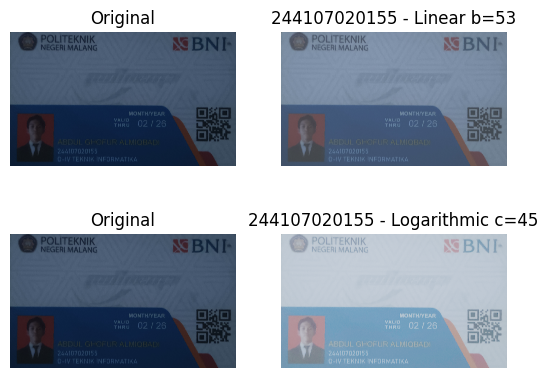

In [ ]:
# baca citra ktm1a
img_a = cv.imread(base + '/KTM1a.jpg')

print('membandingkan linear dan logarithmic brightness')
print('-----------------------------------------------')

# logarithmic: s = c * log(1 + r)
log_img = PARAM['c'] * np.log(1 + img_a.astype(np.float32)) # float32 untuk log
log_img = np.clip(log_img, 0, 255).astype(np.uint8) # ubah lagi ke uint8 untuk gambar

# linear: g = f + b
brightness_array = np.full(img_a.shape, PARAM['b'], np.uint8) # array dummy ukuran sama dengan img_a, isi b semua
lin_img = cv.add(img_a, brightness_array) # cv.add agar tidak wrap-around (ke 0 lagi)

# tampilkan
plt.subplot(2, 2, 1)
plt.imshow(cv.cvtColor(img_a, cv.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(cv.cvtColor(lin_img, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Linear b=' + str(PARAM['b']))
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(cv.cvtColor(img_a, cv.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(cv.cvtColor(log_img, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Logarithmic c=' + str(PARAM['c']))
plt.axis('off')

plt.show()

### Transformasi Grayscale

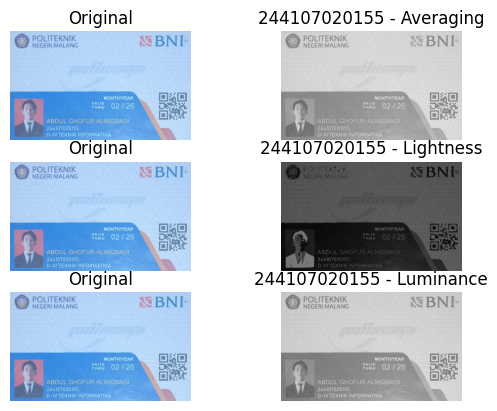

In [ ]:
# baca citra ktm1c
img_c = cv.imread(base + '/KTM1c.jpg')
b, g, r = cv.split(img_c)

avg_img = np.mean(img_c, axis=2).astype(np.uint8)
light_img = ((np.max(img_c, axis=2) + np.min(img_c, axis=2)) / 2).astype(np.uint8)
lum_img = (0.21 * r + 0.72 * g + 0.07 * b).astype(np.uint8)

# tampilkan
plt.subplot(3, 2, 1)
plt.imshow(cv.cvtColor(img_c, cv.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(3, 2, 2)
plt.imshow(cv.cvtColor(avg_img, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Averaging')
plt.axis('off')

plt.subplot(3, 2, 3)
plt.imshow(cv.cvtColor(img_c, cv.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(3, 2, 4)
plt.imshow(cv.cvtColor(light_img, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Lightness')
plt.axis('off')

plt.subplot(3, 2, 5)
plt.imshow(cv.cvtColor(img_c, cv.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(3, 2, 6)
plt.imshow(cv.cvtColor(lum_img, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Luminance')
plt.axis('off')

plt.show()

### Color Masking (HSV)

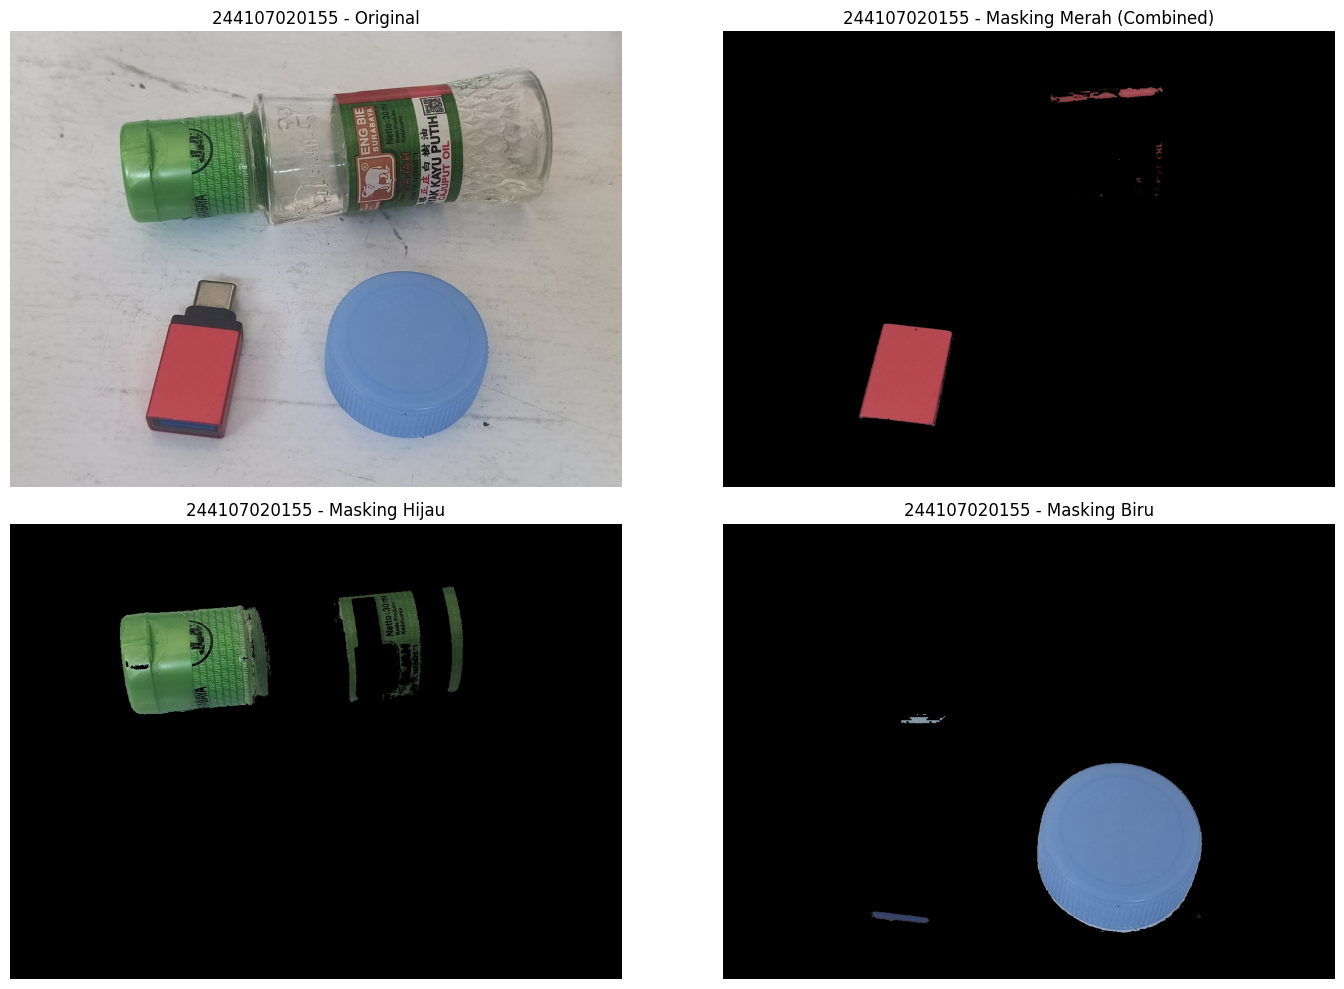

In [ ]:
# Baca citra OBJ1.jpg
Img_obj = cv.imread(base + '/OBJ1.jpg')
hsv_img = cv.cvtColor(Img_obj, cv.COLOR_BGR2HSV)

# 1. Masking MERAH (Gabungan 2 range agar objek merah lebih terlihat)
lower_merah = np.array([170, 100, 100])
upper_merah = np.array([180, 255, 255])
mask_merah = cv.inRange(hsv_img, lower_merah, upper_merah)
res_merah = cv.bitwise_and(Img_obj, Img_obj, mask=mask_merah)

# 2. Masking HIJAU
lower_hijau = np.array([40, 50, 50])
upper_hijau = np.array([80, 255, 255])
mask_hijau = cv.inRange(hsv_img, lower_hijau, upper_hijau)
res_hijau = cv.bitwise_and(Img_obj, Img_obj, mask=mask_hijau)

# 3. Masking BIRU
lower_biru = np.array([100, 50, 50])
upper_biru = np.array([130, 255, 255])
mask_biru = cv.inRange(hsv_img, lower_biru, upper_biru)
res_biru = cv.bitwise_and(Img_obj, Img_obj, mask=mask_biru)

# Tampilkan hasil
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(cv.cvtColor(Img_obj, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Original')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(cv.cvtColor(res_merah, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Masking Merah')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(cv.cvtColor(res_hijau, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Masking Hijau')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(cv.cvtColor(res_biru, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Masking Biru')
plt.axis('off')

plt.tight_layout()
plt.show()

### Gamma Correction

membandingkan linear dan logarithmic brightness
-----------------------------------------------


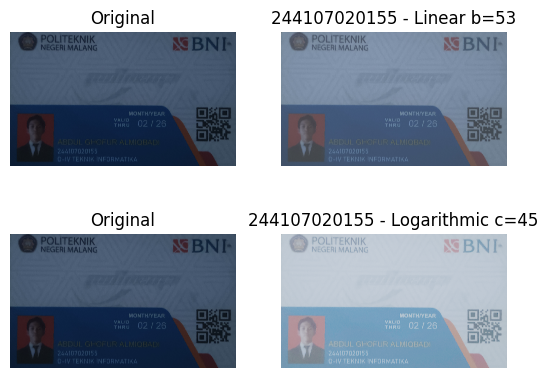

In [ ]:
# baca citra ktm1a
img_a = cv.imread(base + '/KTM1a.jpg')

print('membandingkan linear dan logarithmic brightness')
print('-----------------------------------------------')

# logarithmic: s = c * log(1 + r)
log_img = PARAM['c'] * np.log(1 + img_a.astype(np.float32)) # float32 untuk log
log_img = np.clip(log_img, 0, 255).astype(np.uint8) # ubah lagi ke uint8 untuk gambar

# linear: g = f + b
brightness_array = np.full(img_a.shape, PARAM['b'], np.uint8) # array dummy ukuran sama dengan img_a, isi b semua
lin_img = cv.add(img_a, brightness_array) # cv.add agar tidak wrap-around (ke 0 lagi)

# tampilkan
plt.subplot(2, 2, 1)
plt.imshow(cv.cvtColor(img_a, cv.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(cv.cvtColor(lin_img, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Linear b=' + str(PARAM['b']))
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(cv.cvtColor(img_a, cv.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(cv.cvtColor(log_img, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Logarithmic c=' + str(PARAM['c']))
plt.axis('off')

plt.show()

# fungsi gamma
def gamma_corr(img, gamma):
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    return cv.LUT(img, table)

# coba 5 nilai, misal mulai dari PARAM['gamma']
hasil = gamma_corr(img_a, PARAM['gamma'])

### Simulasi Image Depth

Masukkan bit depth tujuan (1-8): 3
Bit depth awal : 8 bit
Bit depth tujuan : 3 bit
Jumlah level  : 8


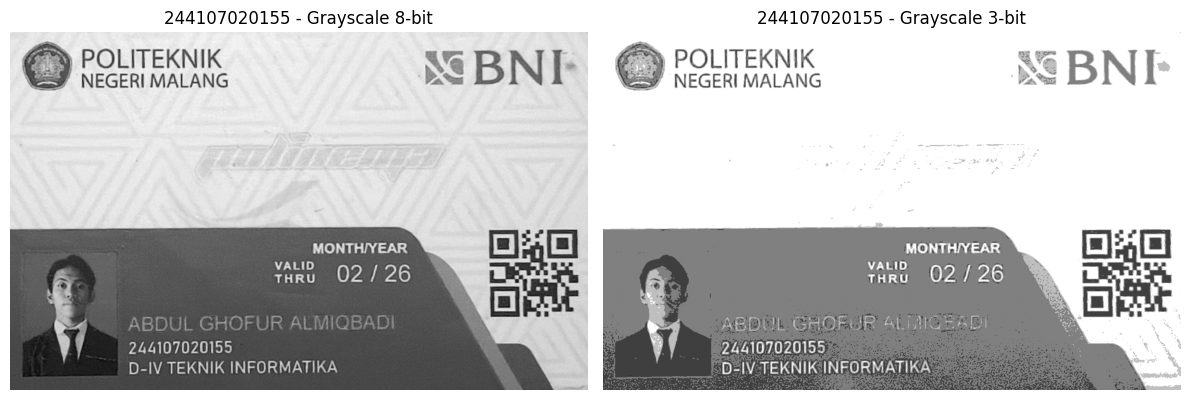

In [ ]:
# baca citra KTM1b grayscale
img_b_gray = cv.imread(base + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)

# input bit depth tujuan
print('Masukkan bit depth tujuan (1-8): ', end='')
try:
    bit_depth_tujuan = int(input())
except ValueError:
    print('Error, not a number')
    bit_depth_tujuan = 4  # default jika error

# hitung level
jumlah_level = pow(2, bit_depth_tujuan)
level = 255 / (jumlah_level - 1)

# konversi bit depth
depth_img = np.round(img_b_gray / level) * level
depth_img = depth_img.astype(np.uint8)

# tampilkan info
print(f'Bit depth awal : 8 bit')
print(f'Bit depth tujuan : {bit_depth_tujuan} bit')
print(f'Jumlah level  : {jumlah_level}')

# tampilkan gambar berdampingan
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_b_gray, cmap='gray')
plt.title(NIM + ' - Grayscale 8-bit')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(depth_img, cmap='gray')
plt.title(NIM + f' - Grayscale {bit_depth_tujuan}-bit')
plt.axis('off')

plt.tight_layout()
plt.show()

### Average Denoising

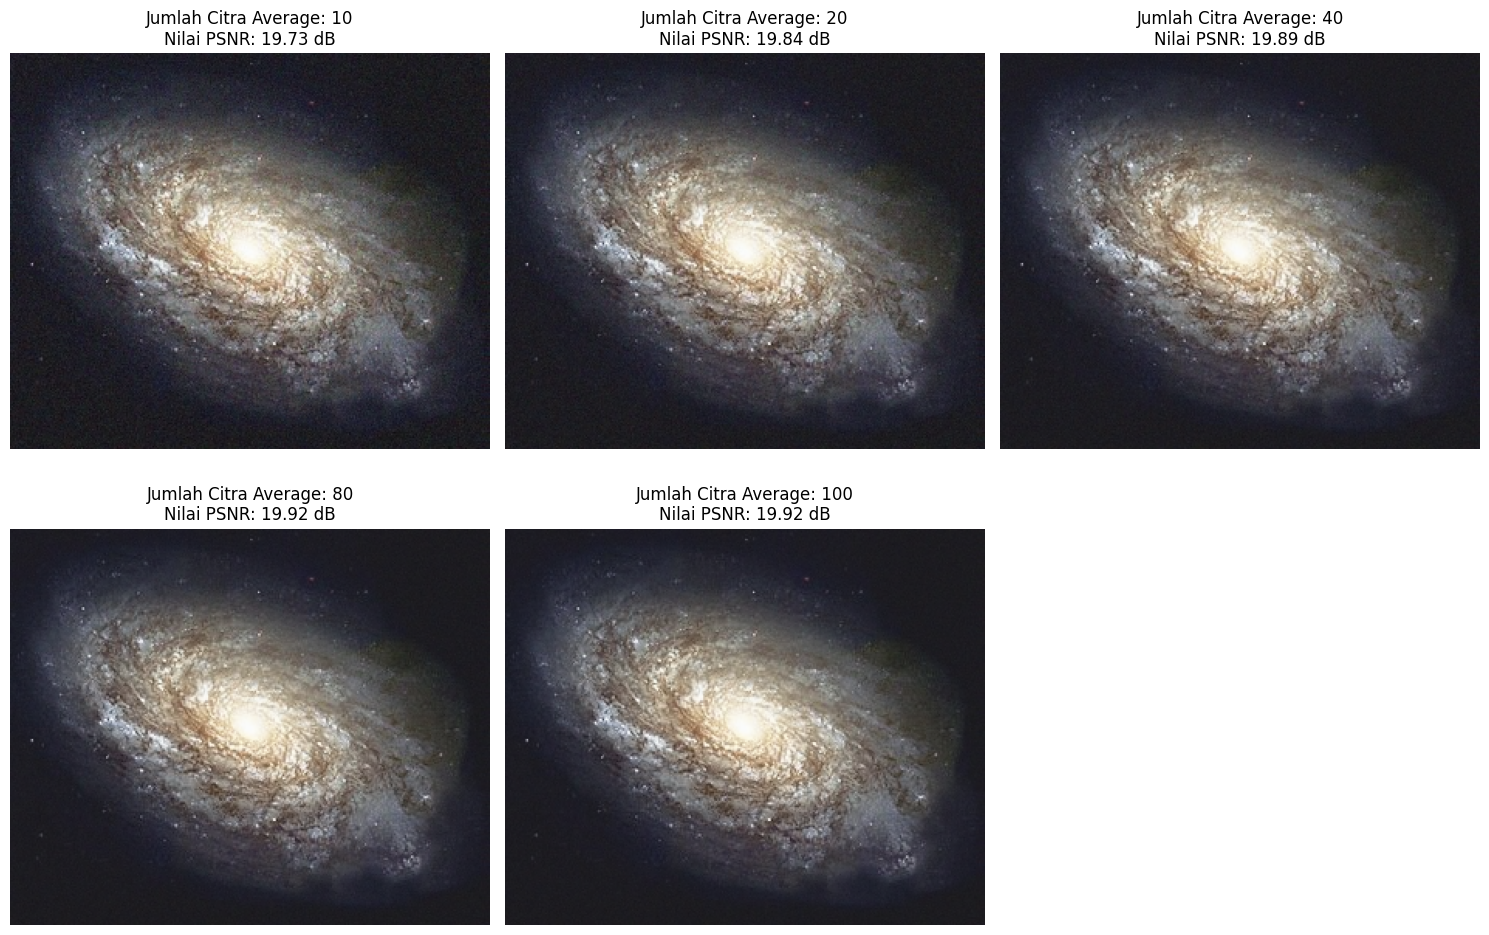

In [ ]:
# fungsi PSNR
def hitung_psnr(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * log10(255.0 / sqrt(mse))

# ambil citra
original = cv.imread(base + '/galaxy.jpg')

cv_img = []
# # ambil citra folder noises
for img in glob.glob(base + '/noises/*.jpg'):
    n = cv.imread(img)
    cv_img.append(n)

# tentukan jumlah citra yang ingin di-average
jumlah_list = [10, 20, 40, 80, 100]

# tampilkan foto dengan judul berisi jumlah average dan nilai PSNR
plt.figure(figsize=(15, 10))

for i, jumlah in enumerate(jumlah_list):
    # lakukan average pada jumlah citra pertama
    avg_img = np.mean(cv_img[:jumlah], axis=0).astype(np.uint8)

    # hitung nilai PSNR antara citra asli dan citra hasil average
    psnr_val = hitung_psnr(original, avg_img)

    # tampilkan foto
    plt.subplot(2, 3, i+1)
    plt.imshow(cv.cvtColor(avg_img, cv.COLOR_BGR2RGB))

    # format judul sesuai permintaan Anda
    plt.title(f"Jumlah Citra Average: {jumlah}\nNilai PSNR: {psnr_val:.2f} dB", fontsize=12)
    plt.axis('off') # Matikan sumbu x dan y agar foto lebih rapi

plt.tight_layout()
plt.show()

### Image Masking

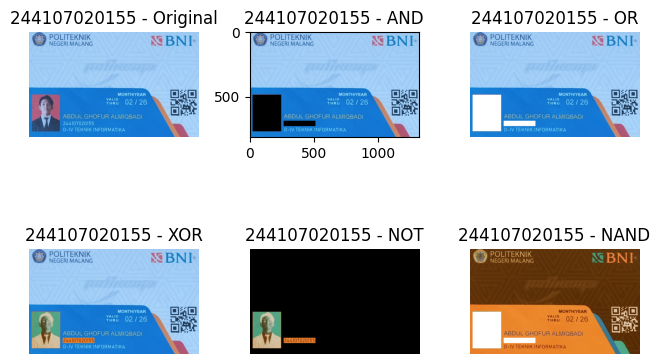

In [ ]:
# ambil citra
img_d = cv.imread(base + '/KTM1d.jpg')

# buat canvas
mask_and = np.ones((img_d.shape[0], img_d.shape[1]), dtype=np.uint8) * 255

cv.rectangle(mask_and, (240, 490), (20, 770), 0, -1)  # area wajah
cv.rectangle(mask_and, (260, 690), (505, 730), 0, -1)  # area nim

# ubah mask ke grayscale
mask_gray = mask_and

# AND
res_and = cv.bitwise_and(img_d, img_d, mask=mask_gray)

# OR
mask_or = cv.bitwise_not(mask_gray)
mask_or_3ch = cv.merge([mask_or, mask_or, mask_or])
res_or = cv.bitwise_or(img_d, mask_or_3ch)

# XOR
res_xor = cv.bitwise_xor(img_d, mask_or_3ch)

# NOT
res_not = cv.bitwise_not(img_d, mask=mask_or)

# NAND
temp_and = cv.bitwise_and(img_d, img_d, mask=mask_gray)
res_nand = cv.bitwise_not(temp_and)

# tampil hasil
plt.figure()

plt.subplot(2, 3, 1)
plt.imshow(cv.cvtColor(img_d, cv.COLOR_BGR2RGB))
plt.title(f'{NIM} - Original')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(cv.cvtColor(res_and, cv.COLOR_BGR2RGB))
plt.title(f'{NIM} - AND')
plt.axis('on')

plt.subplot(2, 3, 3)
plt.imshow(cv.cvtColor(res_or, cv.COLOR_BGR2RGB))
plt.title(f'{NIM} - OR')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(cv.cvtColor(res_xor, cv.COLOR_BGR2RGB))
plt.title(f'{NIM} - XOR')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(cv.cvtColor(res_not, cv.COLOR_BGR2RGB))
plt.title(f'{NIM} - NOT')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(cv.cvtColor(res_nand, cv.COLOR_BGR2RGB))
plt.title(f'{NIM} - NAND')
plt.axis('off')

plt.tight_layout()
plt.show()

### Foto Malam Hari

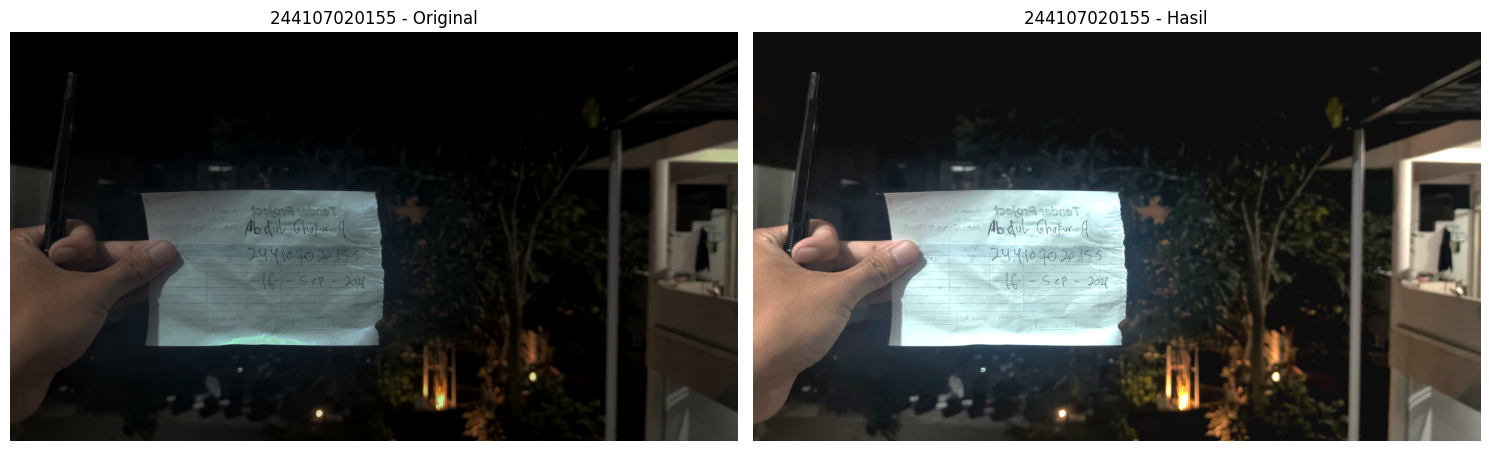

In [33]:
# baca citra malam hari
img_n = cv.imread(base + '/NIGHT1.jpg')

img_hasil = cv.convertScaleAbs(img_n, alpha=1.9, beta=13)

# tampilan hasil
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(cv.cvtColor(img_n, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Original')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(cv.cvtColor(img_hasil, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Hasil')
plt.axis('off')

plt.tight_layout()
plt.show()

### Metode yang dipilih
Saya menggunakan fungsi cv.convertScaleAbs yang menggabungkan operasi Contrast Adjustment dan Linear Brightness dalam satu transformasi linear dengan rumus g(x,y) = α * f(x,y) + β.
### Alasan pemilihan
Foto malam hari memiliki intensitas piksel yang sangat rendah sehingga dengan metode ini dapat mencerahkan area gelap dan memperlebar rentang kontras secara bersamaan dalam satu operasi, sehingga detail yang tersembunyi menjadi jelas tanpa perlu memproses brightness dan contrast secara terpisah.
### Menentukan parameter terbaik
Parameter ditentukan melalui percobaan (trial and error). Nilai alpha (contrast) = 1.9 dipilih untuk memperlebar perbedaan antara piksel gelap dan terang, sedangkan beta (brightness) = 13 dipilih untuk menggeser ke arah yang lebih terang tanpa membuat area yang sudah terang (seperti lampu) mengalami clipping atau putih total.